In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [4]:
df_raw = pd.read_excel('Telco Churn dataset.xlsx')
y = df_raw['Churn'].map({'Yes': 1, 'No': 0})
X_raw = df_raw.drop(columns=['Churn'])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# Moved to preprocessing.py, and imported from there rather than defined
# here — a pipeline pickled with functions defined inside a notebook can't be
# unpickled outside the notebook (joblib only saves a reference to where the
# function lives, and 'the notebook's __main__' doesn't exist elsewhere,
# like inside the API's Docker container). Defining them in a real, importable
# module fixes that.
from preprocessing import (
    clean_total_revenue,
    drop_unneeded_columns,
    collapse_no_internet_service,
    bin_voicemail_messages,
    bin_tenure,
)

In [7]:
from sklearn.compose import make_column_selector
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False), make_column_selector(dtype_include=['object', 'category'])),
    ('num', StandardScaler(), make_column_selector(dtype_include='number'))
])

full_pipeline = Pipeline(steps=[
    ('clean_revenue', FunctionTransformer(clean_total_revenue)),
    ('drop_columns', FunctionTransformer(drop_unneeded_columns)),
    ('collapse_service_cols', FunctionTransformer(collapse_no_internet_service)),
    ('bin_voicemail', FunctionTransformer(bin_voicemail_messages)),
    ('bin_tenure', FunctionTransformer(bin_tenure)),
    ('encode', preprocessor)
])

In [8]:
X_train_processed = full_pipeline.fit_transform(X_train)
X_test_processed = full_pipeline.transform(X_test)

feature_names = full_pipeline.named_steps['encode'].get_feature_names_out()
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

X_train_processed.head()

,cat__gender_Male,cat__MaritalStatus_Yes,cat__Dependents_Yes,cat__MultipleLines_Yes,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_Yes,cat__OnlineBackup_Yes,cat__DeviceProtection_Yes,cat__TechSupport_Yes,...,num__TotalDayMinutes,num__TotalDayCalls,num__TotalEveMinutes,num__TotalEveCalls,num__TotalNightMinutes,num__TotalNightCalls,num__TotalIntlMinutes,num__TotalIntlCalls,num__CustomerServiceCalls,num__TotalRevenue
3283,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.969264,-0.180021,-0.347377,0.544252,0.117165,0.562973,0.985136,-0.990394,-1.195963,3.008760
69,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,-0.894264,0.610974,1.185287,1.100801,0.855515,-0.098009,-0.303266,-0.990394,0.338784,0.130506
1400,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.038413,0.363788,-0.047205,2.416282,0.113216,-0.199698,-0.339055,-0.589058,0.338784,-0.827229
1720,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.473019,0.709848,-1.092836,-2.744450,1.354987,-0.657301,0.448302,-0.187722,2.640906,-0.519062
3006,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.109637,1.352532,1.537144,-1.783137,-0.119739,-1.979265,1.056714,2.220296,0.338784,-0.619390


In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
print(model.intercept_)
print(model.coef_)

[-1.68331414]
[[-0.16522316  0.03593402  0.19602939 -2.59462653  0.85521079 -1.06210541
  -0.24030943 -0.06896843 -0.0309892  -0.5445341   0.14348418  0.44086526
  -0.83127141 -1.81224631  0.11815753 -0.06994326  0.226185   -0.24575232
   1.80349394 -0.47072745 -0.67209858  0.31975416 -0.85189818 -1.04088912
  -0.56951403  0.06012647  0.68499738  0.09322406  0.33987779 -0.03820594
   0.23316092 -0.01515293  0.21552881 -0.20707235  0.62020768 -0.46982644]]


In [11]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    model, X_train_processed, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    key = f'test_{metric}'
    print(f"{metric}: {scores[key].mean():.3f} (+/- {scores[key].std():.3f})")

accuracy: 0.900 (+/- 0.009)
precision: 0.726 (+/- 0.065)
recall: 0.513 (+/- 0.061)
f1: 0.597 (+/- 0.041)
roc_auc: 0.912 (+/- 0.014)


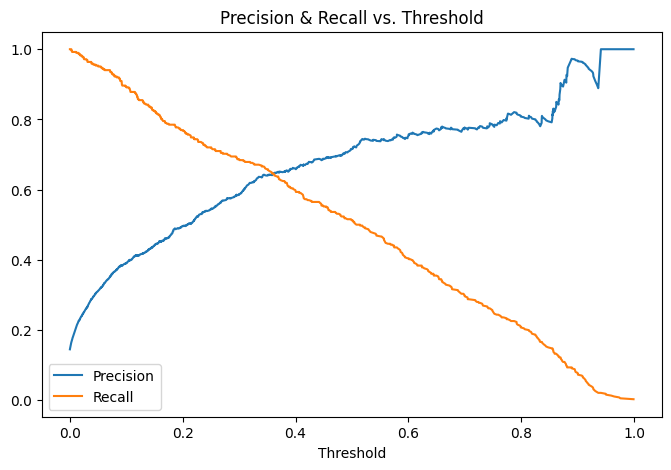

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Honest, out-of-fold probability predictions — each row's prediction comes from
# a model version that never saw that row during its own training.
y_scores = cross_val_predict(model, X_train_processed, y_train, cv=cv, method='predict_proba')[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision & Recall vs. Threshold')
plt.show()

In [13]:
# F2 score: weights recall twice as heavily as precision (beta=2), instead of
# plain recall (no regard for precision at all) or plain F1 (equal weighting).
from sklearn.metrics import fbeta_score, make_scorer

f2_scorer = make_scorer(fbeta_score, beta=2)

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'penalty': ['l2'], 'solver': ['lbfgs'], 'C': [0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'balanced']},
    {'penalty': ['l1'], 'solver': ['liblinear'], 'C': [0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'balanced']},
    {'penalty': ['elasticnet'], 'solver': ['saga'], 'C': [0.01, 0.1, 1, 10, 100], 'l1_ratio': [0.2, 0.5, 0.8], 'class_weight': [None, 'balanced']},
]

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=cv,
    scoring=f2_scorer
)
grid_search.fit(X_train_processed, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F2 score:", grid_search.best_score_)

/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best F2 score: 0.7072234269493192


In [15]:
best_model = grid_search.best_estimator_
print(best_model)

LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


In [16]:
from sklearn.model_selection import cross_validate

tuned_scores = cross_validate(
    best_model, X_train_processed, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    key = f'test_{metric}'
    print(f"{metric}: {tuned_scores[key].mean():.3f} (+/- {tuned_scores[key].std():.3f})")

accuracy: 0.824 (+/- 0.018)
precision: 0.445 (+/- 0.029)
recall: 0.832 (+/- 0.037)
f1: 0.579 (+/- 0.021)
roc_auc: 0.912 (+/- 0.014)


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

log_reg_y_test_pred = best_model.predict(X_test_processed)
log_reg_y_test_proba = best_model.predict_proba(X_test_processed)[:, 1]

print("Test set performance (best_model, never seen this data before):")
print(f"accuracy: {accuracy_score(y_test, log_reg_y_test_pred):.3f}")
print(f"precision: {precision_score(y_test, log_reg_y_test_pred):.3f}")
print(f"recall: {recall_score(y_test, log_reg_y_test_pred):.3f}")
print(f"f1: {f1_score(y_test, log_reg_y_test_pred):.3f}")
print(f"roc_auc: {roc_auc_score(y_test, log_reg_y_test_proba):.3f}")

Test set performance (best_model, never seen this data before):
accuracy: 0.823
precision: 0.442
recall: 0.825
f1: 0.576
roc_auc: 0.911


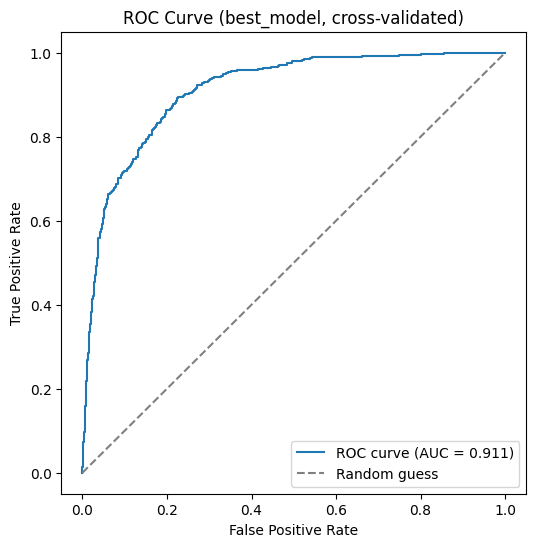

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores_best = cross_val_predict(best_model, X_train_processed, y_train, cv=cv, method='predict_proba')[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_train, y_scores_best)
auc = roc_auc_score(y_train, y_scores_best)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (best_model, cross-validated)')
plt.legend()
plt.show()

In [19]:
# XGBoost is tree-based, so it doesn't need scaled numeric features — only the
# encoding step matters, so this pipeline reuses the same cleaning/binning steps
# but passes numeric columns through unscaled instead of using StandardScaler.
xgb_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', sparse_output=False), make_column_selector(dtype_include=['object', 'category'])),
    ('num', 'passthrough', make_column_selector(dtype_include='number'))
])

xgb_pipeline = Pipeline(steps=[
    ('clean_revenue', FunctionTransformer(clean_total_revenue)),
    ('drop_columns', FunctionTransformer(drop_unneeded_columns)),
    ('collapse_service_cols', FunctionTransformer(collapse_no_internet_service)),
    ('bin_voicemail', FunctionTransformer(bin_voicemail_messages)),
    ('bin_tenure', FunctionTransformer(bin_tenure)),
    ('encode', xgb_preprocessor)
])

X_train_xgb = xgb_pipeline.fit_transform(X_train)
X_test_xgb = xgb_pipeline.transform(X_test)

xgb_feature_names = xgb_pipeline.named_steps['encode'].get_feature_names_out()
X_train_xgb = pd.DataFrame(X_train_xgb, columns=xgb_feature_names, index=X_train.index)
X_test_xgb = pd.DataFrame(X_test_xgb, columns=xgb_feature_names, index=X_test.index)

X_train_xgb.head()

,cat__gender_Male,cat__MaritalStatus_Yes,cat__Dependents_Yes,cat__MultipleLines_Yes,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_Yes,cat__OnlineBackup_Yes,cat__DeviceProtection_Yes,cat__TechSupport_Yes,...,num__TotalDayMinutes,num__TotalDayCalls,num__TotalEveMinutes,num__TotalEveCalls,num__TotalNightMinutes,num__TotalNightCalls,num__TotalIntlMinutes,num__TotalIntlCalls,num__CustomerServiceCalls,num__TotalRevenue
3283,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,232.8,97.0,183.5,111.0,206.8,111.0,13.0,2.0,0.0,7459.05
69,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,130.7,113.0,260.6,122.0,244.2,98.0,9.4,2.0,2.0,1929.35
1400,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,181.8,108.0,198.6,148.0,206.6,96.0,9.3,3.0,2.0,89.35
1720,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,260.4,115.0,146.0,46.0,269.5,87.0,11.5,4.0,5.0,681.40
3006,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,118.9,128.0,278.3,65.0,194.8,61.0,13.2,10.0,2.0,488.65


In [20]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_xgb, y_train)

xgb_scores = cross_validate(
    xgb_model, X_train_xgb, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print("XGBoost performance:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    key = f'test_{metric}'
    print(f"{metric}: {xgb_scores[key].mean():.3f} (+/- {xgb_scores[key].std():.3f})")

/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/utils/_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: XGBClassifier should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict

XGBoost performance:
accuracy: 0.957 (+/- 0.008)
precision: 0.922 (+/- 0.029)
recall: 0.769 (+/- 0.041)
f1: 0.839 (+/- 0.033)
roc_auc: nan (+/- nan)


/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/utils/_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: XGBClassifier should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict

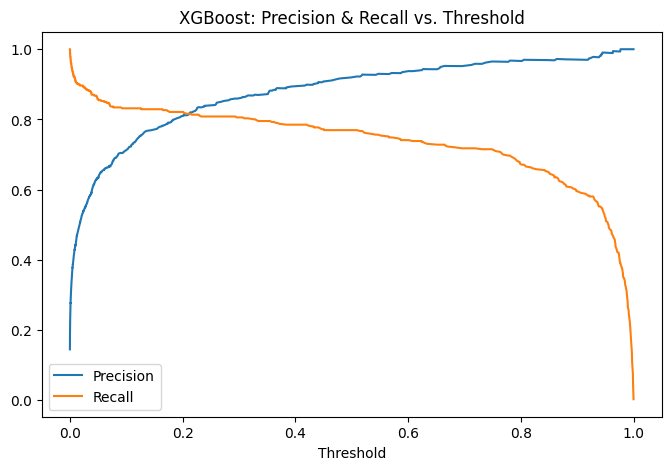

In [21]:
xgb_y_scores = cross_val_predict(xgb_model, X_train_xgb, y_train, cv=cv, method='predict_proba')[:, 1]

xgb_precisions, xgb_recalls, xgb_thresholds = precision_recall_curve(y_train, xgb_y_scores)

plt.figure(figsize=(8, 5))
plt.plot(xgb_thresholds, xgb_precisions[:-1], label='Precision')
plt.plot(xgb_thresholds, xgb_recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('XGBoost: Precision & Recall vs. Threshold')
plt.show()

In [22]:
xgb_param_grid = {
    'scale_pos_weight': [1, 3, 6, 10],
    'max_depth': [3, 5, 7]
}

xgb_grid_search = GridSearchCV(
    XGBClassifier(random_state=42),
    xgb_param_grid,
    cv=cv,
    scoring=f2_scorer
)
xgb_grid_search.fit(X_train_xgb, y_train)

print("Best parameters:", xgb_grid_search.best_params_)
print("Best F2 score:", xgb_grid_search.best_score_)

Best parameters: {'max_depth': 7, 'scale_pos_weight': 10}
Best F2 score: 0.8265390177562792


In [23]:
xgb_best_model = xgb_grid_search.best_estimator_

xgb_tuned_scores = cross_validate(
    xgb_best_model, X_train_xgb, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print("Tuned XGBoost performance:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    key = f'test_{metric}'
    print(f"{metric}: {xgb_tuned_scores[key].mean():.3f} (+/- {xgb_tuned_scores[key].std():.3f})")

/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/utils/_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: XGBClassifier should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict

Tuned XGBoost performance:
accuracy: 0.955 (+/- 0.010)
precision: 0.864 (+/- 0.051)
recall: 0.819 (+/- 0.044)
f1: 0.839 (+/- 0.032)
roc_auc: nan (+/- nan)


/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 400, in _score
    y_pred = method_caller(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/sklearn/utils/_response.py", line 235, in _get_response_values
    raise ValueError(
ValueError: XGBClassifier should either be a classifier to be used with response_method=predict_proba or the response_method should be 'predict

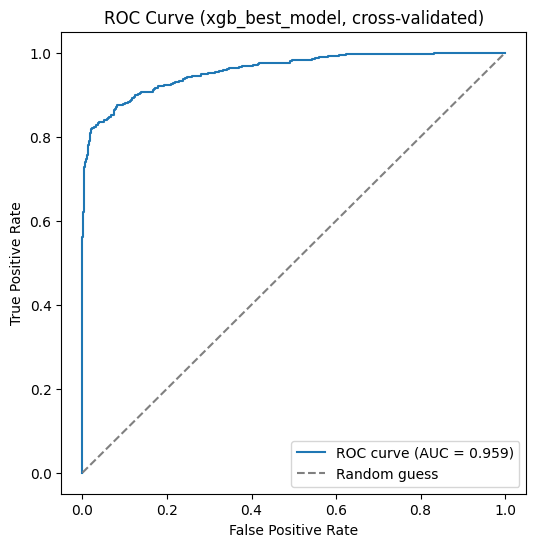

In [24]:
xgb_y_scores_best = cross_val_predict(xgb_best_model, X_train_xgb, y_train, cv=cv, method='predict_proba')[:, 1]

xgb_fpr, xgb_tpr, xgb_roc_thresholds = roc_curve(y_train, xgb_y_scores_best)
xgb_auc = roc_auc_score(y_train, xgb_y_scores_best)

plt.figure(figsize=(6, 6))
plt.plot(xgb_fpr, xgb_tpr, label=f'ROC curve (AUC = {xgb_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (xgb_best_model, cross-validated)')
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_y_test_pred = xgb_best_model.predict(X_test_xgb)
xgb_y_test_proba = xgb_best_model.predict_proba(X_test_xgb)[:, 1]

print("Test set performance (xgb_best_model, never seen this data before):")
print(f"accuracy: {accuracy_score(y_test, xgb_y_test_pred):.3f}")
print(f"precision: {precision_score(y_test, xgb_y_test_pred):.3f}")
print(f"recall: {recall_score(y_test, xgb_y_test_pred):.3f}")
print(f"f1: {f1_score(y_test, xgb_y_test_pred):.3f}")
print(f"roc_auc: {roc_auc_score(y_test, xgb_y_test_proba):.3f}")

Test set performance (xgb_best_model, never seen this data before):
accuracy: 0.952
precision: 0.865
recall: 0.794
f1: 0.828
roc_auc: 0.962


In [26]:
xgb_tuned_precisions, xgb_tuned_recalls, xgb_tuned_thresholds = precision_recall_curve(y_train, xgb_y_scores_best)

target_recall = 0.95
idx = (np.abs(xgb_tuned_recalls[:-1] - target_recall)).argmin()

print(f"Threshold: {xgb_tuned_thresholds[idx]:.3f}")
print(f"Recall at that threshold: {xgb_tuned_recalls[idx]:.3f}")
print(f"Precision at that threshold: {xgb_tuned_precisions[idx]:.3f}")

Threshold: 0.003
Recall at that threshold: 0.951
Precision at that threshold: 0.340


In [27]:
# Same threshold search, but for the tuned logistic regression model, so we can
# compare precision against XGBoost at a matched recall level.
log_reg_precisions, log_reg_recalls, log_reg_thresholds = precision_recall_curve(y_train, y_scores_best)

idx_log_reg = (np.abs(log_reg_recalls[:-1] - target_recall)).argmin()

print(f"Threshold: {log_reg_thresholds[idx_log_reg]:.3f}")
print(f"Recall at that threshold: {log_reg_recalls[idx_log_reg]:.3f}")
print(f"Precision at that threshold: {log_reg_precisions[idx_log_reg]:.3f}")

Threshold: 0.223
Recall at that threshold: 0.951
Precision at that threshold: 0.318


In [28]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_xgb, y_train)

lgbm_scores = cross_validate(
    lgbm_model, X_train_xgb, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print("LightGBM performance:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    key = f'test_{metric}'
    print(f"{metric}: {lgbm_scores[key].mean():.3f} (+/- {lgbm_scores[key].std():.3f})")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 386, number of negative: 2280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 2666, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.144786 -> initscore=-1.776093
[LightGBM] [Info] Start training from score -1.776093
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 308, number of negative: 1824
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001056 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1540
[LightGBM] [Info] Numb

In [29]:
lgbm_y_test_pred = lgbm_model.predict(X_test_xgb)
lgbm_y_test_proba = lgbm_model.predict_proba(X_test_xgb)[:, 1]

print("Test set performance (lgbm_model, never seen this data before):")
print(f"accuracy: {accuracy_score(y_test, lgbm_y_test_pred):.3f}")
print(f"precision: {precision_score(y_test, lgbm_y_test_pred):.3f}")
print(f"recall: {recall_score(y_test, lgbm_y_test_pred):.3f}")
print(f"f1: {f1_score(y_test, lgbm_y_test_pred):.3f}")
print(f"roc_auc: {roc_auc_score(y_test, lgbm_y_test_proba):.3f}")

Test set performance (lgbm_model, never seen this data before):
accuracy: 0.957
precision: 0.947
recall: 0.742
f1: 0.832
roc_auc: 0.968


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 308, number of negative: 1824
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1540
[LightGBM] [Info] Number of data points in the train set: 2132, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.144465 -> initscore=-1.778687
[LightGBM] [Info] Start training from score -1.778687
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 309, number of negative: 1824
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1542
[LightGBM] [Info] Numb

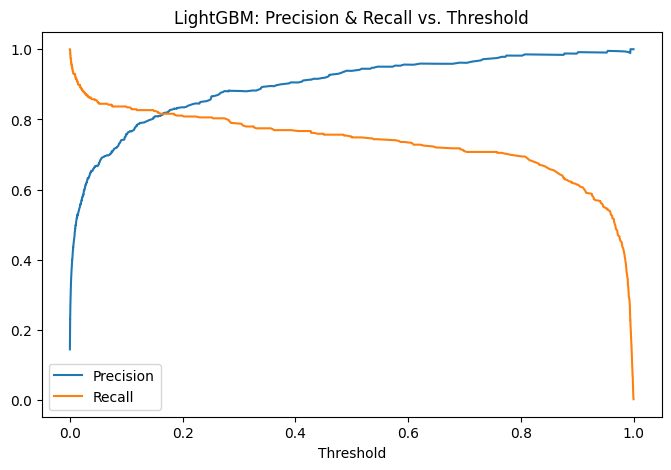

In [30]:
lgbm_y_scores_cv = cross_val_predict(lgbm_model, X_train_xgb, y_train, cv=cv, method='predict_proba')[:, 1]

lgbm_precisions, lgbm_recalls, lgbm_thresholds = precision_recall_curve(y_train, lgbm_y_scores_cv)

plt.figure(figsize=(8, 5))
plt.plot(lgbm_thresholds, lgbm_precisions[:-1], label='Precision')
plt.plot(lgbm_thresholds, lgbm_recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('LightGBM: Precision & Recall vs. Threshold')
plt.show()

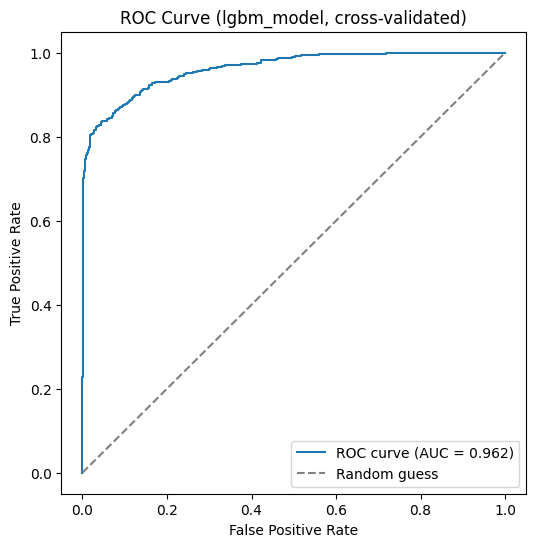

In [31]:
lgbm_fpr, lgbm_tpr, lgbm_roc_thresholds = roc_curve(y_train, lgbm_y_scores_cv)
lgbm_auc = roc_auc_score(y_train, lgbm_y_scores_cv)

plt.figure(figsize=(6, 6))
plt.plot(lgbm_fpr, lgbm_tpr, label=f'ROC curve (AUC = {lgbm_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (lgbm_model, cross-validated)')
plt.legend()
plt.show()

In [32]:
lgbm_target_recall = 0.92
lgbm_idx = (np.abs(lgbm_recalls[:-1] - lgbm_target_recall)).argmin()

print(f"Threshold: {lgbm_thresholds[lgbm_idx]:.3f}")
print(f"Recall at that threshold: {lgbm_recalls[lgbm_idx]:.3f}")
print(f"Precision at that threshold: {lgbm_precisions[lgbm_idx]:.3f}")

Threshold: 0.010
Recall at that threshold: 0.920
Precision at that threshold: 0.497


In [33]:
lgbm_param_grid = {
    'scale_pos_weight': [1, 3, 6, 10],
    'max_depth': [3, 5, 7]
}

lgbm_grid_search = GridSearchCV(
    LGBMClassifier(random_state=42),
    lgbm_param_grid,
    cv=cv,
    scoring=f2_scorer
)
lgbm_grid_search.fit(X_train_xgb, y_train)

print("Best parameters:", lgbm_grid_search.best_params_)
print("Best F2 score:", lgbm_grid_search.best_score_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 308, number of negative: 1824
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1540
[LightGBM] [Info] Number of data points in the train set: 2132, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.144465 -> initscore=-1.778687
[LightGBM] [Info] Start training from score -1.778687
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [34]:
lgbm_best_model = lgbm_grid_search.best_estimator_

lgbm_tuned_scores = cross_validate(
    lgbm_best_model, X_train_xgb, y_train, cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

print("Tuned LightGBM performance:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    key = f'test_{metric}'
    print(f"{metric}: {lgbm_tuned_scores[key].mean():.3f} (+/- {lgbm_tuned_scores[key].std():.3f})")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 308, number of negative: 1824
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1540
[LightGBM] [Info] Number of data points in the train set: 2132, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.144465 -> initscore=-1.778687
[LightGBM] [Info] Start training from score -1.778687
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [35]:
lgbm_best_y_test_pred = lgbm_best_model.predict(X_test_xgb)
lgbm_best_y_test_proba = lgbm_best_model.predict_proba(X_test_xgb)[:, 1]

print("Test set performance (lgbm_best_model, never seen this data before):")
print(f"accuracy: {accuracy_score(y_test, lgbm_best_y_test_pred):.3f}")
print(f"precision: {precision_score(y_test, lgbm_best_y_test_pred):.3f}")
print(f"recall: {recall_score(y_test, lgbm_best_y_test_pred):.3f}")
print(f"f1: {f1_score(y_test, lgbm_best_y_test_pred):.3f}")
print(f"roc_auc: {roc_auc_score(y_test, lgbm_best_y_test_proba):.3f}")

Test set performance (lgbm_best_model, never seen this data before):
accuracy: 0.928
precision: 0.729
recall: 0.804
f1: 0.765
roc_auc: 0.966


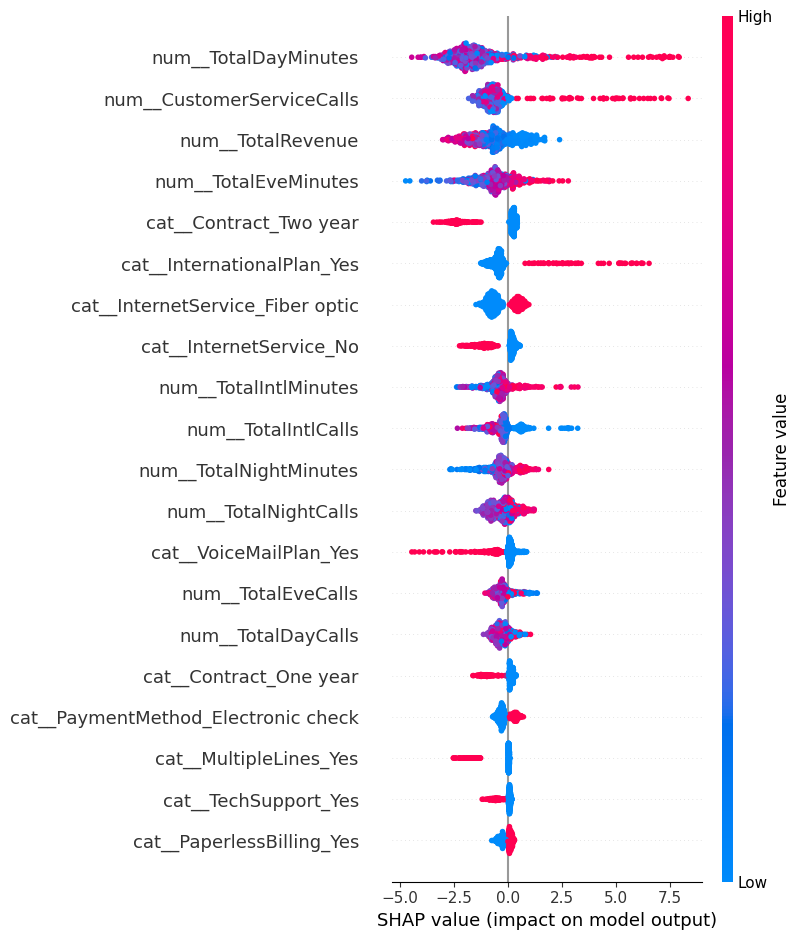

In [36]:
import shap

xgb_explainer = shap.TreeExplainer(xgb_best_model)
xgb_shap_values = xgb_explainer.shap_values(X_test_xgb)

shap.summary_plot(xgb_shap_values, X_test_xgb)

/Users/praavinkumar/anaconda3/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


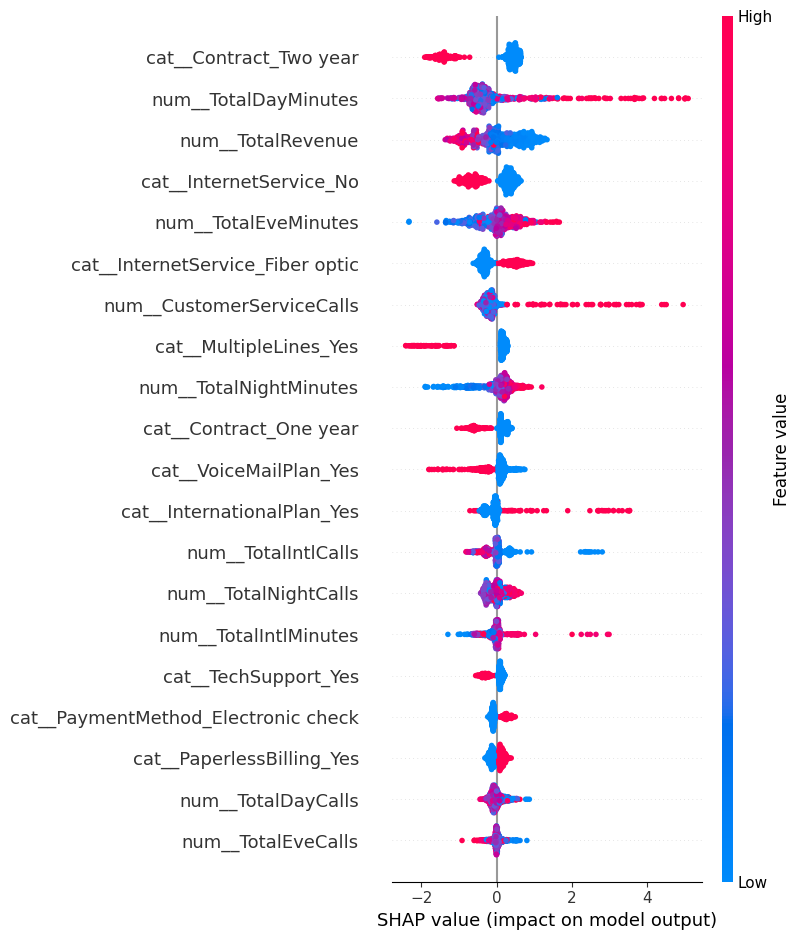

In [37]:
lgbm_explainer = shap.TreeExplainer(lgbm_best_model)
lgbm_shap_values = lgbm_explainer.shap_values(X_test_xgb)

shap.summary_plot(lgbm_shap_values, X_test_xgb)

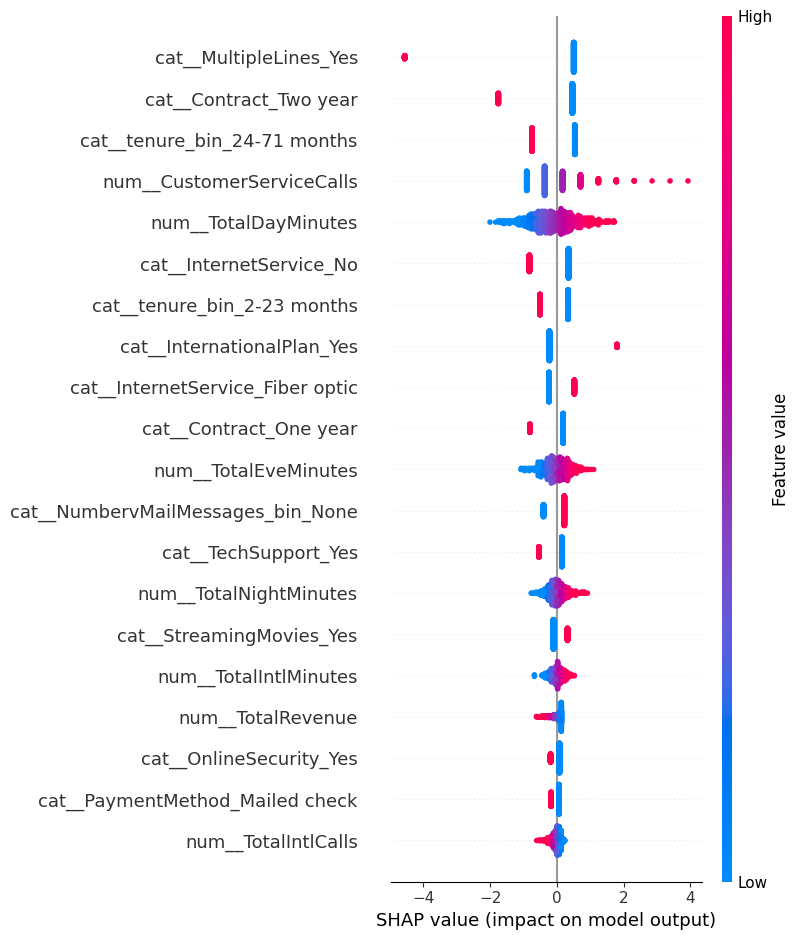

In [38]:
# LinearExplainer instead of TreeExplainer — best_model is a linear model
# (logistic regression), not a tree ensemble, so it needs the background
# training data to compute each feature's average contribution.
log_reg_explainer = shap.LinearExplainer(best_model, X_train_processed)
log_reg_shap_values = log_reg_explainer.shap_values(X_test_processed)

shap.summary_plot(log_reg_shap_values, X_test_processed)

In [40]:
# sklearn's LogisticRegression has no built-in significance testing (it's built
# for prediction, not inference) — statsmodels' Logit gives a Wald z-test and
# p-value for every coefficient via .summary().
#
# Two columns get dropped before this fit, for two different reasons:
# - 'NumbervMailMessages_bin_None' is perfectly collinear with 'VoiceMailPlan_Yes'
#   (0 voicemail messages and no voicemail plan are the same fact stated twice) —
#   combined with the intercept, that makes the design matrix singular.
# - 'MultipleLines_Yes' and 'tenure_bin_72 months (censored)' show perfect
#   separation: every customer with either of these is Churn=0 in the training
#   data, so the MLE optimizer pushes their coefficients toward infinity and
#   never converges. Classical MLE can't handle this — it's a known statistical
#   limitation, not a bug — so these are excluded from this specific test.
import statsmodels.api as sm

X_train_for_wald = X_train_processed.drop(columns=[
    'cat__NumbervMailMessages_bin_None',
    'cat__MultipleLines_Yes',
    'cat__tenure_bin_72 months (censored)'
])
X_train_with_const = sm.add_constant(X_train_for_wald)
logit_model = sm.Logit(y_train, X_train_with_const)
logit_results = logit_model.fit()

print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.239302
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 2666
Model:                          Logit   Df Residuals:                     2632
Method:                           MLE   Df Model:                           33
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                  0.4214
Time:                        15:43:35   Log-Likelihood:                -637.98
converged:                       True   LL-Null:                       -1102.5
Covariance Type:            nonrobust   LLR p-value:                7.593e-174
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const                                       

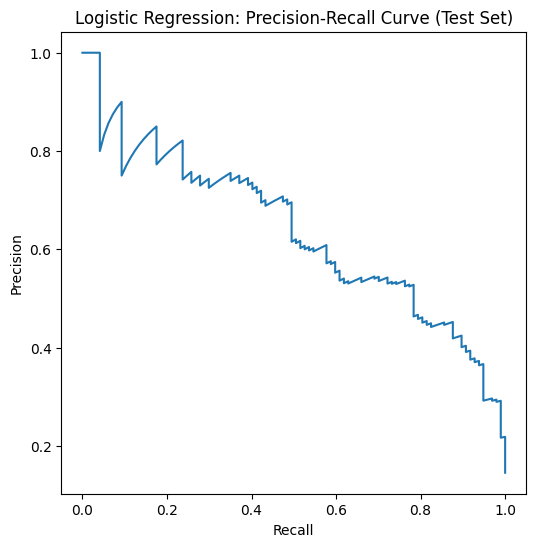

In [42]:
# Logistic Regression: Precision-Recall curve on the held-out test set.
test_pr_precisions_lr, test_pr_recalls_lr, _ = precision_recall_curve(y_test, log_reg_y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(test_pr_recalls_lr, test_pr_precisions_lr)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Logistic Regression: Precision-Recall Curve (Test Set)')
plt.show()

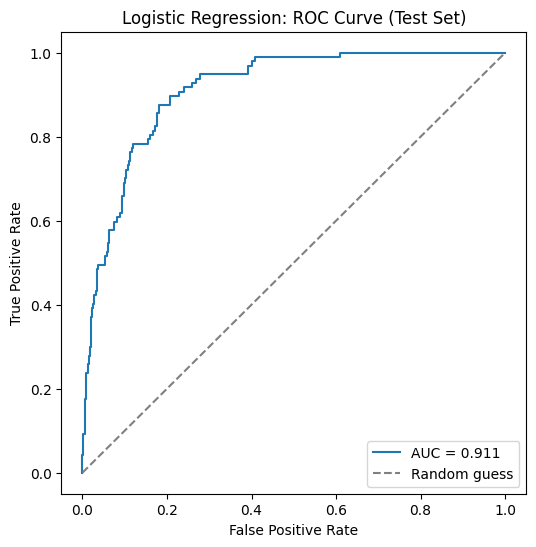

In [43]:
# Logistic Regression: ROC curve on the held-out test set.
test_roc_fpr_lr, test_roc_tpr_lr, _ = roc_curve(y_test, log_reg_y_test_proba)
test_auc_lr = roc_auc_score(y_test, log_reg_y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(test_roc_fpr_lr, test_roc_tpr_lr, label=f'AUC = {test_auc_lr:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression: ROC Curve (Test Set)')
plt.legend()
plt.show()

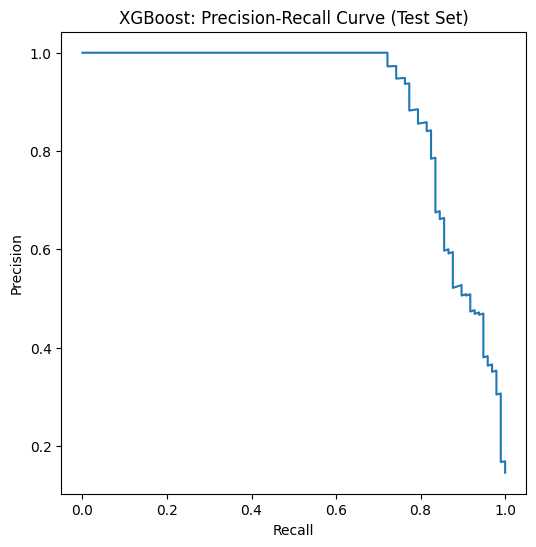

In [44]:
# XGBoost: Precision-Recall curve on the held-out test set.
test_pr_precisions_xgb, test_pr_recalls_xgb, _ = precision_recall_curve(y_test, xgb_y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(test_pr_recalls_xgb, test_pr_precisions_xgb)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('XGBoost: Precision-Recall Curve (Test Set)')
plt.show()

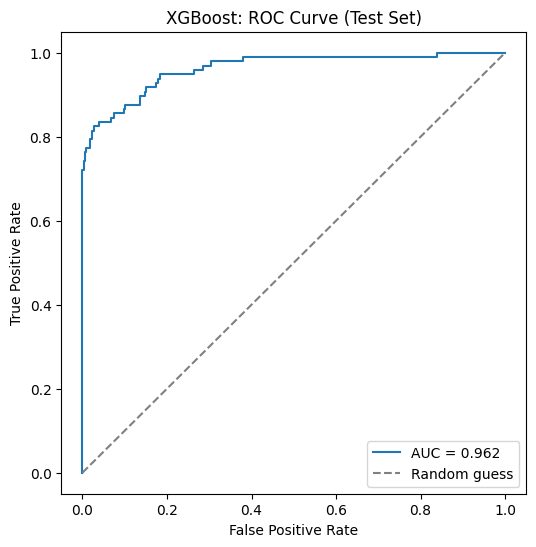

In [45]:
# XGBoost: ROC curve on the held-out test set.
test_roc_fpr_xgb, test_roc_tpr_xgb, _ = roc_curve(y_test, xgb_y_test_proba)
test_auc_xgb = roc_auc_score(y_test, xgb_y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(test_roc_fpr_xgb, test_roc_tpr_xgb, label=f'AUC = {test_auc_xgb:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost: ROC Curve (Test Set)')
plt.legend()
plt.show()

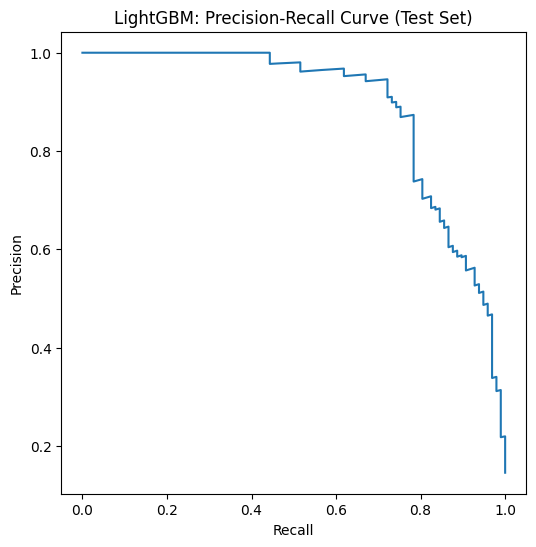

In [46]:
# LightGBM: Precision-Recall curve on the held-out test set.
test_pr_precisions_lgbm, test_pr_recalls_lgbm, _ = precision_recall_curve(y_test, lgbm_best_y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(test_pr_recalls_lgbm, test_pr_precisions_lgbm)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('LightGBM: Precision-Recall Curve (Test Set)')
plt.show()

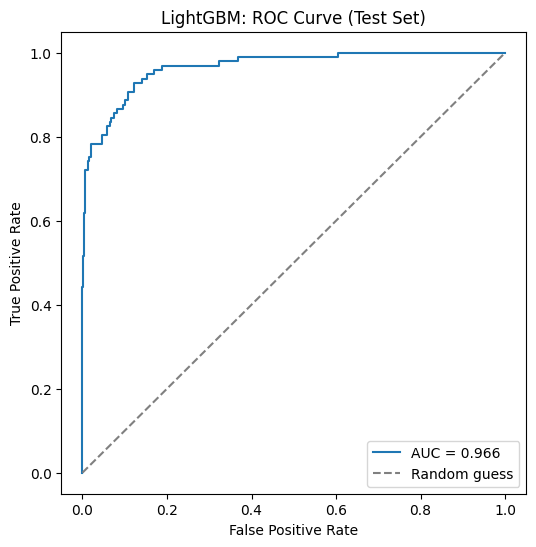

In [47]:
# LightGBM: ROC curve on the held-out test set.
test_roc_fpr_lgbm, test_roc_tpr_lgbm, _ = roc_curve(y_test, lgbm_best_y_test_proba)
test_auc_lgbm = roc_auc_score(y_test, lgbm_best_y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(test_roc_fpr_lgbm, test_roc_tpr_lgbm, label=f'AUC = {test_auc_lgbm:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LightGBM: ROC Curve (Test Set)')
plt.legend()
plt.show()

In [48]:
import joblib

# Save the fitted preprocessing pipeline and the tuned XGBoost model separately —
# the API will load both and chain them together at prediction time.
joblib.dump(xgb_pipeline, 'xgb_pipeline.joblib')
joblib.dump(xgb_best_model, 'xgb_best_model.joblib')
print("Saved xgb_pipeline.joblib and xgb_best_model.joblib")

Saved xgb_pipeline.joblib and xgb_best_model.joblib


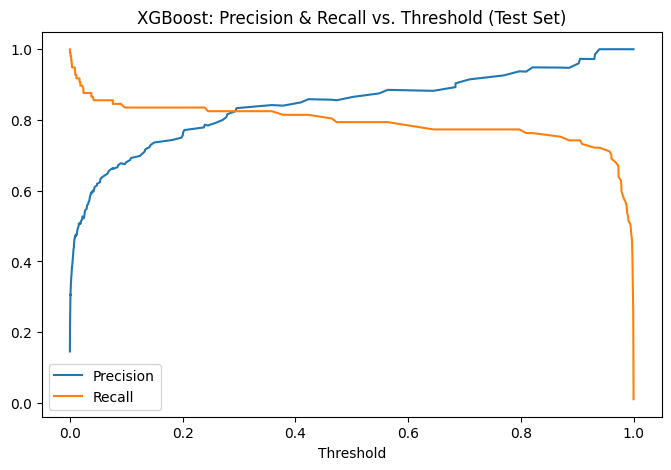

In [49]:
# Precision & recall vs. threshold, for xgb_best_model on the held-out test set.
xgb_test_precisions, xgb_test_recalls, xgb_test_thresholds = precision_recall_curve(y_test, xgb_y_test_proba)

plt.figure(figsize=(8, 5))
plt.plot(xgb_test_thresholds, xgb_test_precisions[:-1], label='Precision')
plt.plot(xgb_test_thresholds, xgb_test_recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('XGBoost: Precision & Recall vs. Threshold (Test Set)')
plt.show()

In [50]:
# Find the threshold on the TEST set that gets XGBoost's recall to ~0.85 —
# a moderate lean toward recall, favoring catching churners over the default
# 0.5 threshold, without collapsing precision the way a more extreme target
# (like 0.95) would.
xgb_target_recall = 0.85
xgb_deploy_idx = (np.abs(xgb_test_recalls[:-1] - xgb_target_recall)).argmin()

xgb_deploy_threshold = xgb_test_thresholds[xgb_deploy_idx]
print(f"Threshold: {xgb_deploy_threshold:.3f}")
print(f"Recall at that threshold: {xgb_test_recalls[xgb_deploy_idx]:.3f}")
print(f"Precision at that threshold: {xgb_test_precisions[xgb_deploy_idx]:.3f}")

Threshold: 0.076
Recall at that threshold: 0.845
Precision at that threshold: 0.661


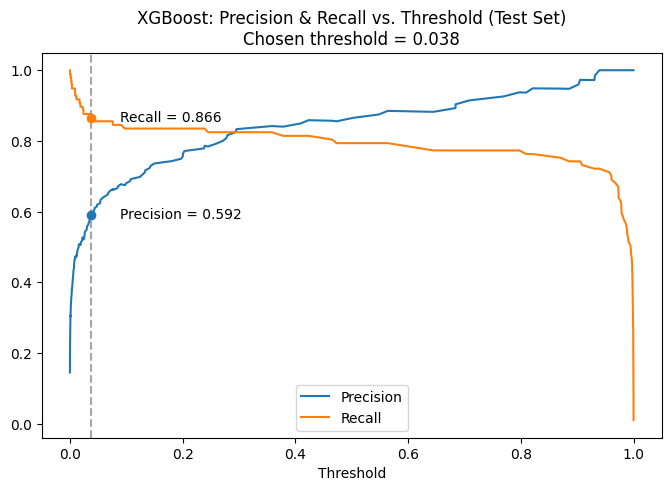

In [51]:
# Same Precision & Recall vs. Threshold plot, but with the chosen deployment
# threshold (0.038) marked — showing exactly how the precision and recall
# values at that point were read off the curves.
chosen_threshold = 0.038
chosen_idx = (np.abs(xgb_test_thresholds - chosen_threshold)).argmin()
precision_at_chosen = xgb_test_precisions[chosen_idx]
recall_at_chosen = xgb_test_recalls[chosen_idx]

plt.figure(figsize=(8, 5))
plt.plot(xgb_test_thresholds, xgb_test_precisions[:-1], label='Precision')
plt.plot(xgb_test_thresholds, xgb_test_recalls[:-1], label='Recall')

# Vertical line at the chosen threshold, and dots where it crosses each curve.
plt.axvline(chosen_threshold, color='gray', linestyle='--', alpha=0.7)
plt.scatter([chosen_threshold], [precision_at_chosen], color='tab:blue', zorder=5)
plt.scatter([chosen_threshold], [recall_at_chosen], color='tab:orange', zorder=5)
plt.annotate(f'Precision = {precision_at_chosen:.3f}',
             xy=(chosen_threshold, precision_at_chosen), xytext=(chosen_threshold + 0.05, precision_at_chosen),
             va='center')
plt.annotate(f'Recall = {recall_at_chosen:.3f}',
             xy=(chosen_threshold, recall_at_chosen), xytext=(chosen_threshold + 0.05, recall_at_chosen),
             va='center')

plt.xlabel('Threshold')
plt.legend()
plt.title(f'XGBoost: Precision & Recall vs. Threshold (Test Set)\nChosen threshold = {chosen_threshold}')
plt.show()